# Figure 5: Data Fidelity — Expression and Type Preservation

| Panel | Content |
|---|---|
| **5A** | Pearson R vs Spearman ρ deviation scatter |
| **5B** | Metadata type preservation rate |
| **5C** | FFI type degradation mechanism (schematic) |
| **5D** | Bidirectional roundtrip: Exact Match % (55 datasets) |


In [1]:
import warnings
warnings.filterwarnings('ignore')

import json, os, re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from matplotlib.lines import Line2D

RESULTS_DIR = Path('/benchmark/results')
FIGURES_DIR_MAIN = Path('/benchmark/figures/main')
FIGURES_DIR_SUPP = Path('/benchmark/figures/supplementary')

for d in [RESULTS_DIR, FIGURES_DIR_MAIN, FIGURES_DIR_SUPP]:
    d.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'font.size': 10, 'axes.labelsize': 11,
    'axes.titlesize': 12, 'figure.dpi': 150,
    'savefig.dpi': 300, 'savefig.bbox': 'tight',
})

COLORS = {
    'CrossCell': '#025e8d', 'Zellkonverter': '#f58220',
    'anndataR': '#00a69d', 'convert2anndata': '#785ba7',
    'easySCF': '#c75301',
}

LABEL_SIZE = 12; TITLE_SIZE = 13; TICK_SIZE = 10
LEGEND_SIZE = 9; ANNOT_SIZE = 8; NOTE_SIZE = 8
FIGURES_DIR = FIGURES_DIR_MAIN
print('\u2705 Setup complete')


✅ Setup complete


## 1. Load Data


In [2]:
# CrossCell roundtrip (detailed)
with open(RESULTS_DIR / 'roundtrip_fidelity.json') as f:
    fidelity_data = json.load(f)
df_rds_rt = pd.DataFrame(fidelity_data['rds_roundtrip'])
df_h5ad_rt = pd.DataFrame(fidelity_data['h5ad_roundtrip'])

# Cross-tool fidelity (42 datasets x 5 tools)
with open(RESULTS_DIR / 'multi_tool_fidelity.json') as f:
    multi_data = json.load(f)
df_cc_rt = pd.DataFrame(multi_data['crosscell_roundtrip'])
df_cross = pd.DataFrame(multi_data['cross_tool'])

# Type preservation data
SUPP4_FILE = RESULTS_DIR / 'type_fidelity.json'
with open(SUPP4_FILE) as f:
    type_data = json.load(f)

print(f'Expression: {len(df_cc_rt)} CC + {len(df_cross)} cross-tool')
print(f'Type preservation: {list(type_data["retention"].keys())}')


Expression: 42 CC + 145 cross-tool
Type preservation: ['CrossCell', 'Zellkonverter', 'anndataR', 'convert2anndata', 'easySCF']


## 2. Fig 5A: Expression Fidelity — Correlation Deviation


Saved fig5a


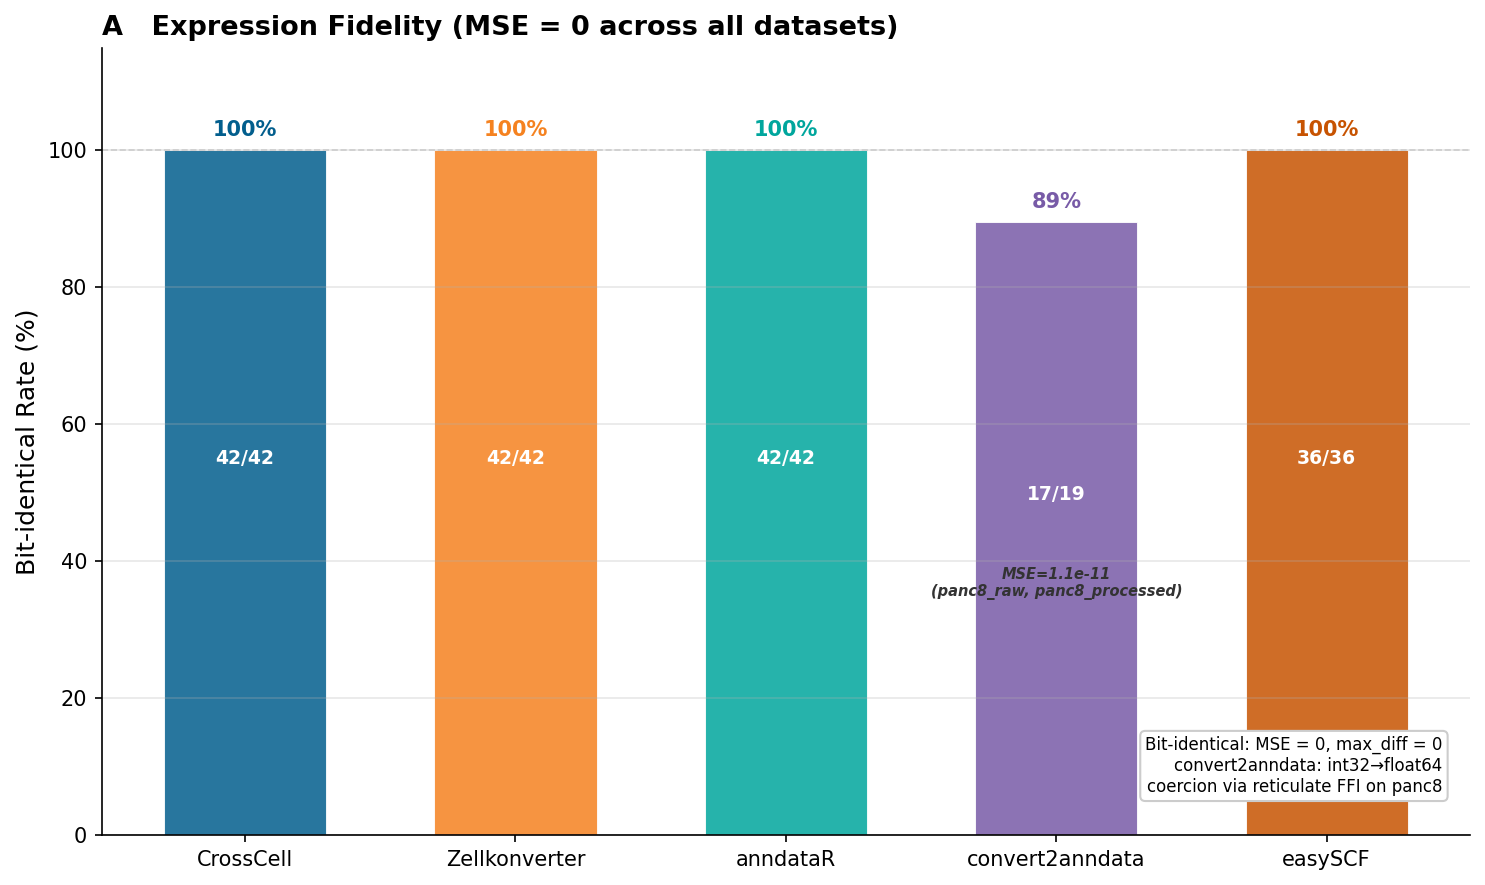

In [3]:
tool_order = ['CrossCell', 'Zellkonverter', 'anndataR', 'convert2anndata', 'easySCF']

# Build dataframe with MSE per tool per dataset
rows_dev = []
for _, e in df_cc_rt.iterrows():
    rows_dev.append({'tool': 'CrossCell', 'test_id': e['test_id'], 'mse': e['mse'],
                     'max_diff': e['max_diff']})
for _, e in df_cross[df_cross['status'] == 'success'].iterrows():
    rows_dev.append({'tool': e['tool'], 'test_id': e['test_id'], 'mse': e['mse'],
                     'max_diff': e['max_diff']})
df_dev = pd.DataFrame(rows_dev)

# Compute bit-identical rate per tool
bit_rates = []
bit_details = []
for tool in tool_order:
    sub = df_dev[df_dev['tool'] == tool]
    n_perfect = (sub['mse'] == 0).sum()
    n_total = len(sub)
    rate = 100.0 * n_perfect / n_total if n_total > 0 else 0
    bit_rates.append(rate)
    # Find non-zero MSE datasets
    nonzero = sub[sub['mse'] > 0]
    detail = {'n_perfect': n_perfect, 'n_total': n_total, 'nonzero': nonzero}
    bit_details.append(detail)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(tool_order))
bar_colors = [COLORS[t] for t in tool_order]

bars = ax.bar(x, bit_rates, 0.6, color=bar_colors, alpha=0.85,
              edgecolor='white', linewidth=0.5)

for i, (tool, rate, detail) in enumerate(zip(tool_order, bit_rates, bit_details)):
    # Rate label above bar
    ax.text(i, rate + 1.5, f'{rate:.0f}%', ha='center', va='bottom',
            fontsize=10, fontweight='bold', color=COLORS[tool])
    # n/total inside bar
    ax.text(i, rate / 2 + 5, f'{detail["n_perfect"]}/{detail["n_total"]}',
            ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    # If not 100%, show what went wrong
    if rate < 100:
        nonzero = detail['nonzero']
        ds_names = nonzero['test_id'].str.replace('v5_', '').tolist()
        max_mse = nonzero['mse'].max()
        ax.text(i, rate / 2 - 8, f'MSE={max_mse:.1e}\n({", ".join(ds_names)})',
                ha='center', va='center', fontsize=7, color='#333333',
                fontweight='bold', style='italic')

ax.set_xticks(x)
ax.set_xticklabels(tool_order, fontsize=TICK_SIZE)
ax.set_ylabel('Bit-identical Rate (%)', fontsize=LABEL_SIZE)
ax.set_ylim(0, 115)
ax.axhline(y=100, color='#cccccc', linestyle='--', linewidth=0.8)
ax.set_title('A   Expression Fidelity (MSE = 0 across all datasets)',
             fontweight='bold', loc='left', fontsize=TITLE_SIZE)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.text(0.98, 0.05,
        'Bit-identical: MSE = 0, max_diff = 0\n'
        'convert2anndata: int32→float64\n'
        'coercion via reticulate FFI on panc8',
        transform=ax.transAxes, fontsize=NOTE_SIZE, va='bottom', ha='right',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#cccccc'))

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'fig5a_bit_identical_rate.pdf', bbox_inches='tight')
fig.savefig(FIGURES_DIR / 'fig5a_bit_identical_rate.png', bbox_inches='tight')
print('Saved fig5a')
plt.show()


## 3. Fig 5B: Metadata Type Preservation


Saved fig5b


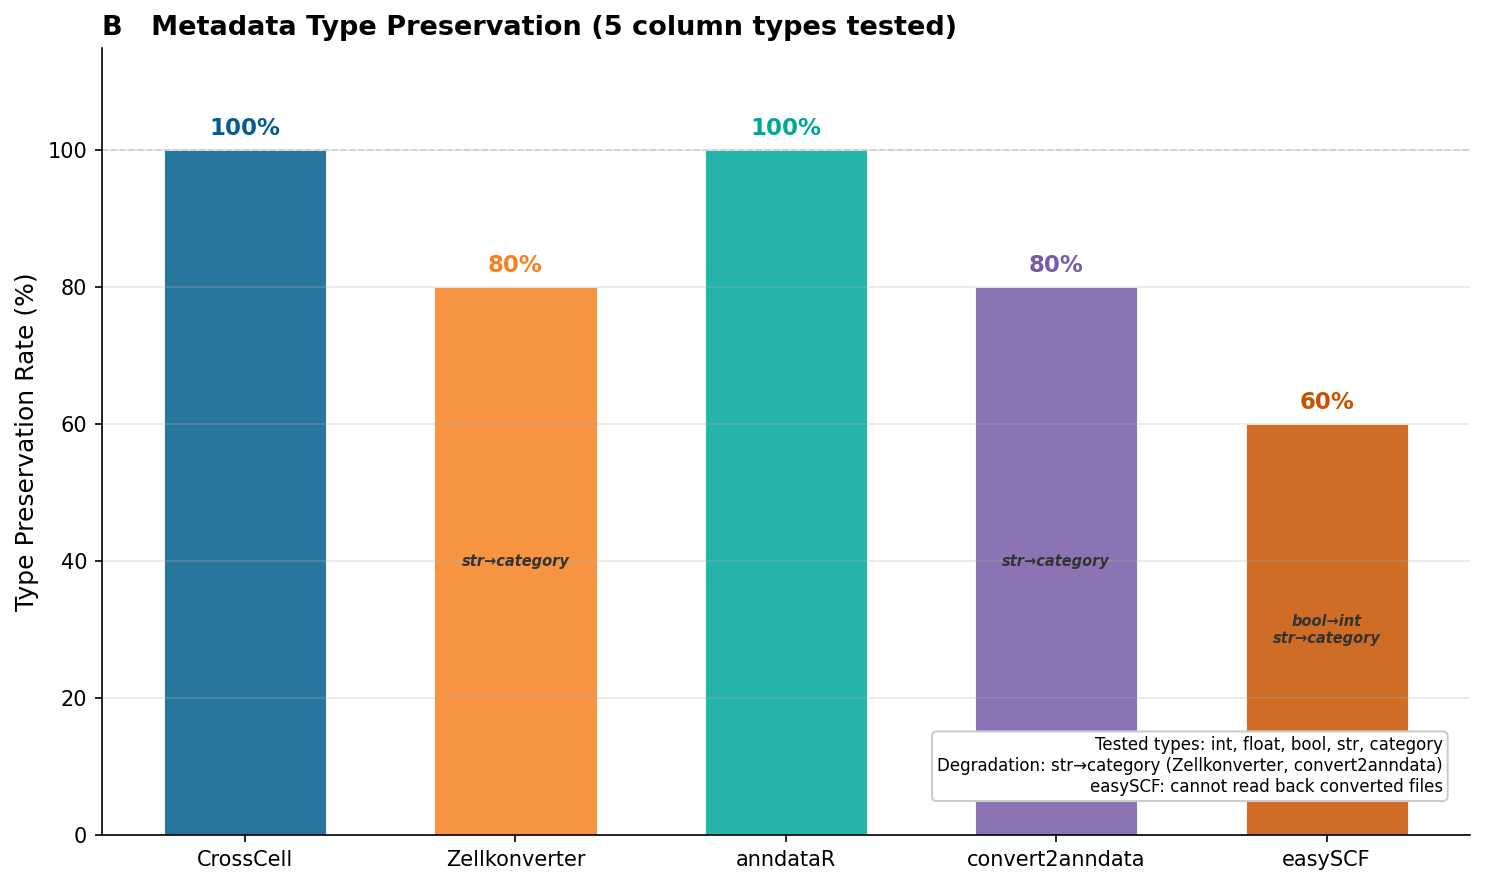

In [4]:
tool_order = ['CrossCell', 'Zellkonverter', 'anndataR', 'convert2anndata', 'easySCF']
retention = type_data['retention']
type_results = type_data['type_results']
expected = type_data['expected_types']

rates = [retention[t] for t in tool_order]

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(tool_order))
bars = ax.bar(x, rates, 0.6, color=[COLORS[t] for t in tool_order],
              alpha=0.85, edgecolor='white', linewidth=0.5)

# Annotate rate + degradation details on each bar
for i, (tool, rate) in enumerate(zip(tool_order, rates)):
    # Rate on top
    ax.text(i, rate + 1.5, f'{rate:.0f}%', ha='center', va='bottom',
            fontsize=11, fontweight='bold', color=COLORS[tool])
    # Degradation details below bar top
    actual = type_results[tool]
    degraded = []
    for col, exp_type in expected.items():
        act_type = actual.get(col, 'missing')
        if act_type == 'READ_ERROR':
            degraded.append(f'{col}: READ ERROR')
        elif act_type != exp_type:
            degraded.append(f'{exp_type}\u2192{act_type}')
    if degraded and rate > 0:
        detail = '\n'.join(degraded)
        ax.text(i, rate / 2, detail, ha='center', va='center',
                fontsize=7, color='#333333', fontweight='bold', style='italic')
    elif rate == 0:
        ax.text(i, 5, 'ALL\nREAD\nERROR', ha='center', va='bottom',
                fontsize=8, color='white', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(tool_order, fontsize=TICK_SIZE)
ax.set_ylabel('Type Preservation Rate (%)', fontsize=LABEL_SIZE)
ax.set_ylim(0, 115)
ax.set_title('B   Metadata Type Preservation (5 column types tested)',
             fontweight='bold', loc='left', fontsize=TITLE_SIZE)

# Reference line at 100%
ax.axhline(y=100, color='#cccccc', linestyle='--', linewidth=0.8)

ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Type legend
ax.text(0.98, 0.05, 'Tested types: int, float, bool, str, category\n'
        'Degradation: str\u2192category (Zellkonverter, convert2anndata)\n'
        'easySCF: cannot read back converted files',
        transform=ax.transAxes, fontsize=NOTE_SIZE, va='bottom', ha='right',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#cccccc'))

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'fig5b_type_preservation.pdf')
fig.savefig(FIGURES_DIR / 'fig5b_type_preservation.png')
print('Saved fig5b')
plt.show()


## 4. Fig 5C: FFI Type Degradation Mechanism


Saved fig5c


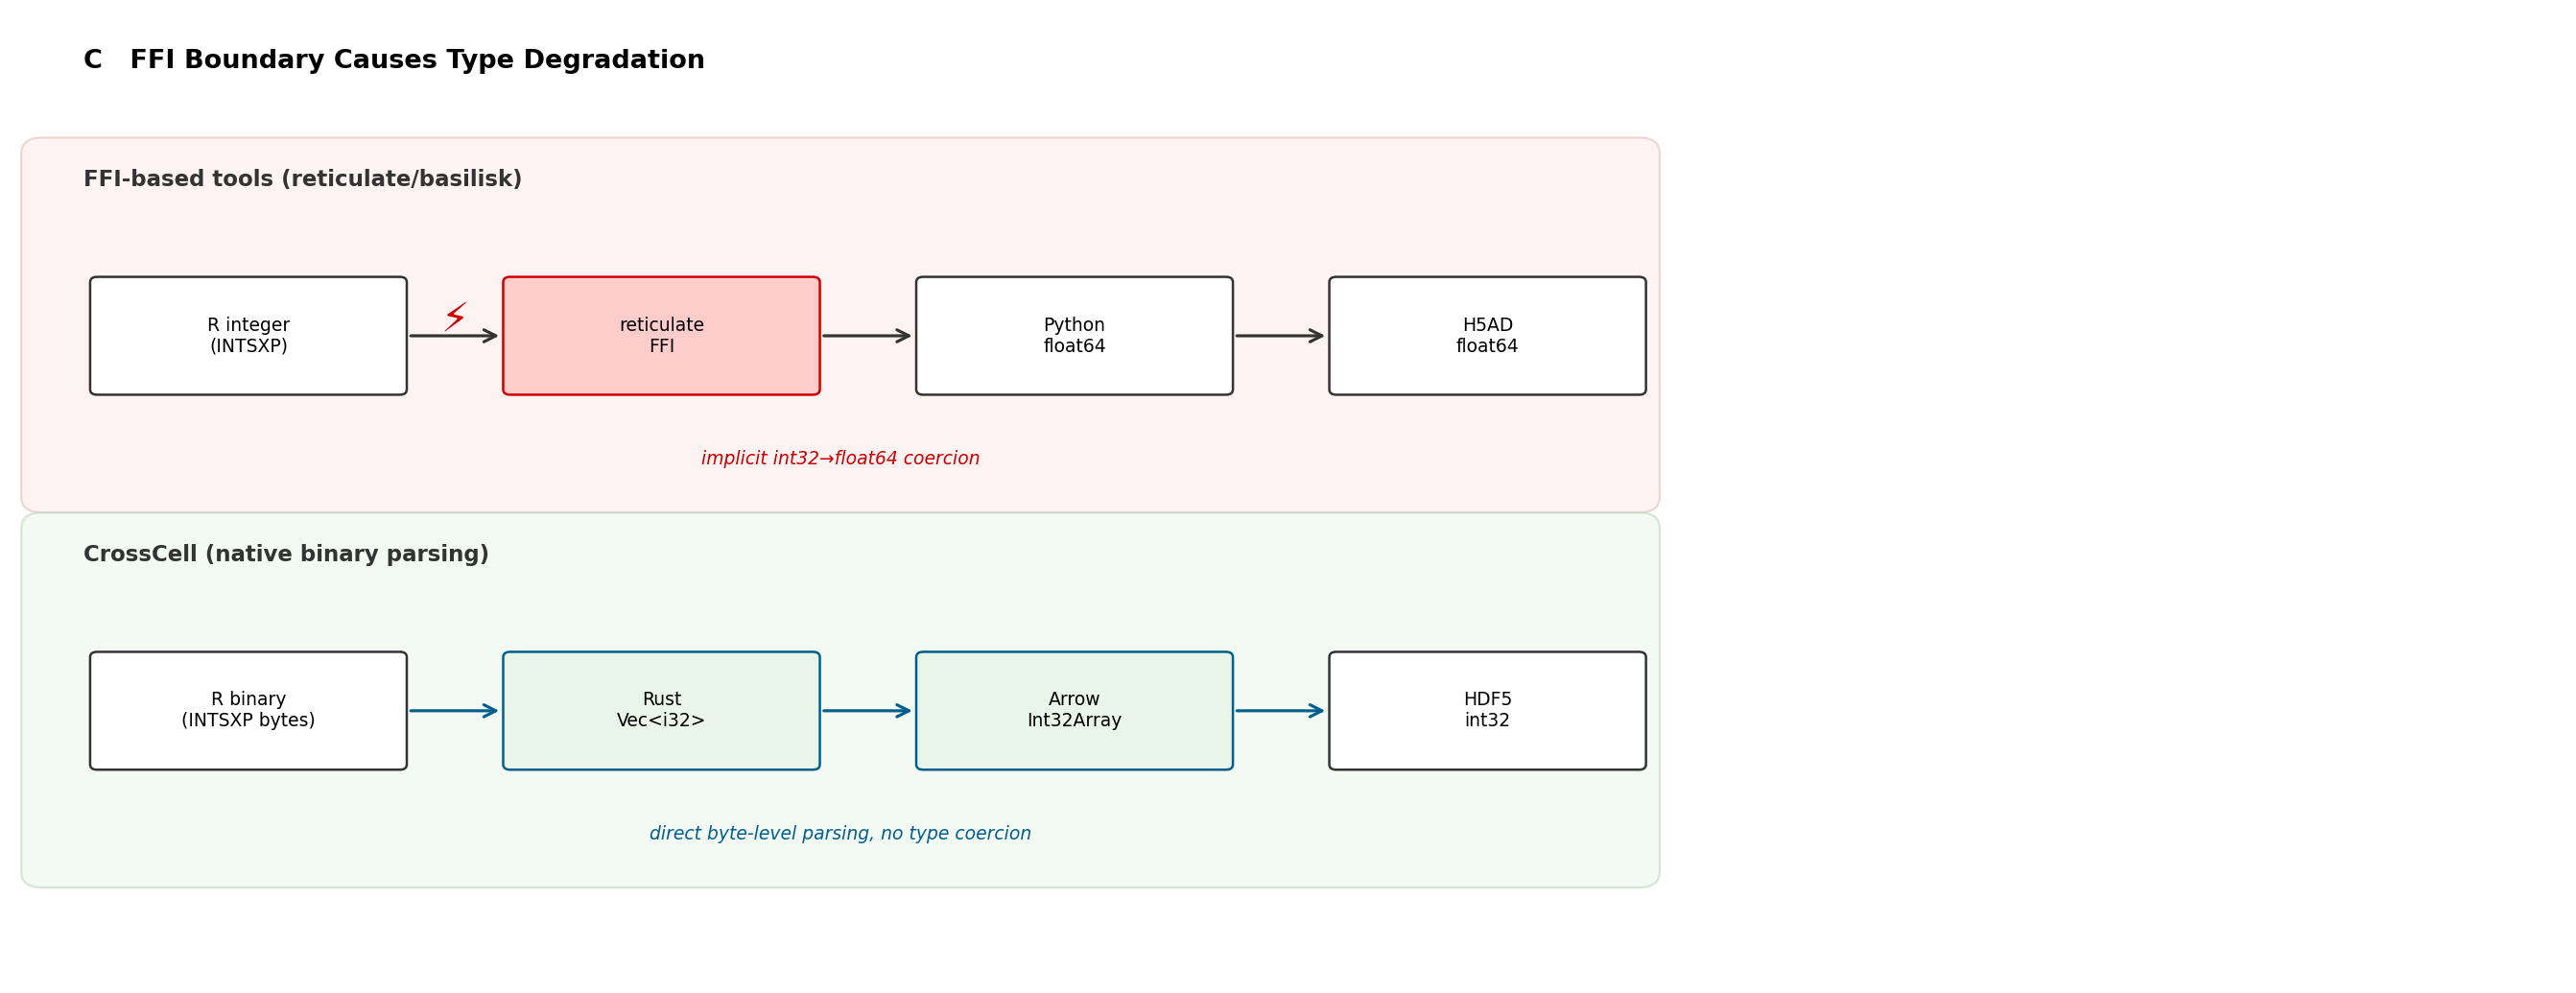

In [5]:
def draw_box(ax, x, y, w, h, text, facecolor='white', edgecolor='black', fontsize=9, bold=False):
    box = FancyBboxPatch((x - w/2, y - h/2), w, h,
                         boxstyle='round,pad=0.05', facecolor=facecolor,
                         edgecolor=edgecolor, linewidth=1.2)
    ax.add_patch(box)
    fw = 'bold' if bold else 'normal'
    ax.text(x, y, text, ha='center', va='center', fontsize=fontsize, fontweight=fw)

def draw_arrow(ax, x1, y1, x2, y2, color='black'):
    arrow = FancyArrowPatch((x1, y1), (x2, y2),
                            arrowstyle='->', mutation_scale=15,
                            color=color, linewidth=1.5)
    ax.add_patch(arrow)

fig, ax = plt.subplots(figsize=(18, 7))
ax.set_xlim(-0.5, 18)
ax.set_ylim(-1, 8)
ax.axis('off')

ax.text(0, 7.5, 'C   FFI Boundary Causes Type Degradation',
        fontsize=TITLE_SIZE, fontweight='bold')

# ---- Top path: FFI-based tools ----
bg_top = FancyBboxPatch((-0.3, 3.5), 11.6, 3.2,
                         boxstyle='round,pad=0.15', facecolor='#fde8e8',
                         edgecolor='#e0b0b0', linewidth=1, alpha=0.5)
ax.add_patch(bg_top)
ax.text(0, 6.4, 'FFI-based tools (reticulate/basilisk)', fontsize=11,
        fontweight='bold', color='#333333')

bw, bh = 2.2, 1.0
y_top = 5.0
boxes_top = [
    (1.2, y_top, 'R integer\n(INTSXP)', 'white', '#333333'),
    (4.2, y_top, 'reticulate\nFFI', '#ffcccc', '#cc0000'),
    (7.2, y_top, 'Python\nfloat64', 'white', '#333333'),
    (10.2, y_top, 'H5AD\nfloat64', 'white', '#333333'),
]
for bx, by, txt, fc, ec in boxes_top:
    draw_box(ax, bx, by, bw, bh, txt, facecolor=fc, edgecolor=ec, fontsize=9)
for i in range(len(boxes_top) - 1):
    x1 = boxes_top[i][0] + bw/2 + 0.05
    x2 = boxes_top[i+1][0] - bw/2 - 0.05
    draw_arrow(ax, x1, y_top, x2, y_top, color='#333333')
ax.text(2.7, y_top + 0.15, '\u26a1', fontsize=20, ha='center', va='center', color='#cc0000')
ax.text(5.5, 3.8, 'implicit int32\u2192float64 coercion', fontsize=9, color='#cc0000',
        style='italic', ha='center')

# ---- Bottom path: CrossCell ----
bg_bot = FancyBboxPatch((-0.3, 0.0), 11.6, 3.2,
                         boxstyle='round,pad=0.15', facecolor='#e8f5e8',
                         edgecolor='#b0d0b0', linewidth=1, alpha=0.5)
ax.add_patch(bg_bot)
ax.text(0, 2.9, 'CrossCell (native binary parsing)', fontsize=11,
        fontweight='bold', color='#333333')

y_bot = 1.5
boxes_bot = [
    (1.2, y_bot, 'R binary\n(INTSXP bytes)', 'white', '#333333'),
    (4.2, y_bot, 'Rust\nVec<i32>', '#e8f5e8', '#025e8d'),
    (7.2, y_bot, 'Arrow\nInt32Array', '#e8f5e8', '#025e8d'),
    (10.2, y_bot, 'HDF5\nint32', 'white', '#333333'),
]
for bx, by, txt, fc, ec in boxes_bot:
    draw_box(ax, bx, by, bw, bh, txt, facecolor=fc, edgecolor=ec, fontsize=9)
for i in range(len(boxes_bot) - 1):
    x1 = boxes_bot[i][0] + bw/2 + 0.05
    x2 = boxes_bot[i+1][0] - bw/2 - 0.05
    draw_arrow(ax, x1, y_bot, x2, y_bot, color='#025e8d')
ax.text(5.5, 0.3, 'direct byte-level parsing, no type coercion', fontsize=9,
        color='#025e8d', style='italic', ha='center')

# Data evidence box on the right
retention = type_data['retention']

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'fig5c_ffi_mechanism.pdf')
fig.savefig(FIGURES_DIR / 'fig5c_ffi_mechanism.png')
print('Saved fig5c')
plt.show()


## 5. Fig 5D: Bidirectional Roundtrip — Exact Match %

Saved fig5d


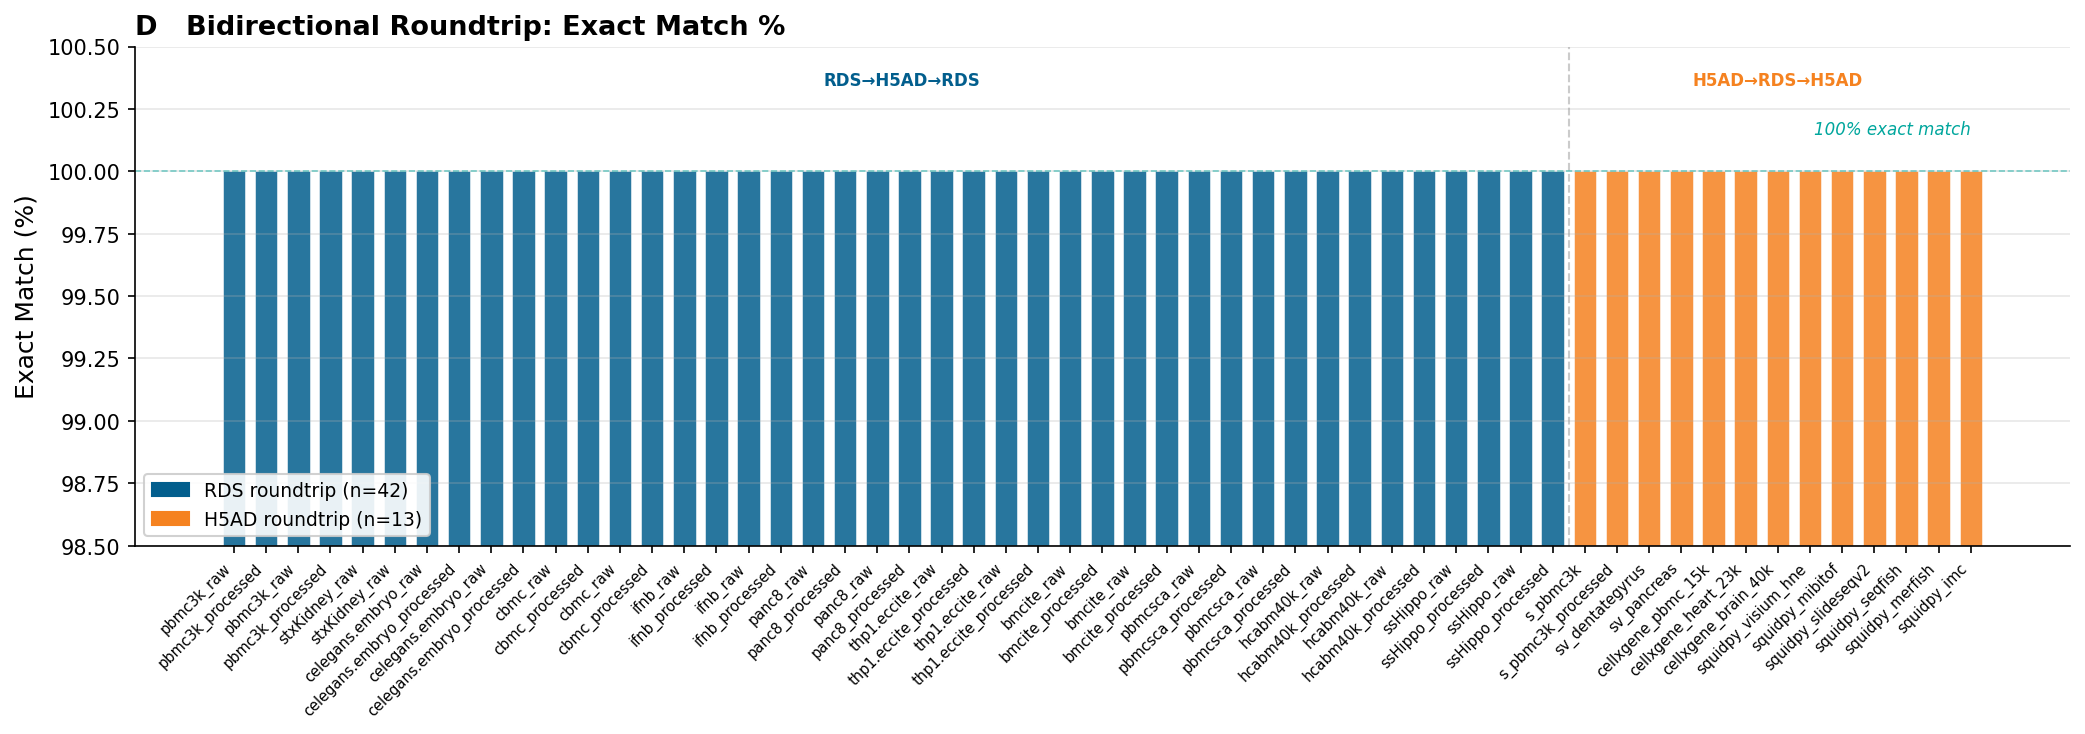

In [6]:

# ── Panel D: Exact Match % (55 datasets, single Y-axis) ──
datasets_rds = df_rds_rt['dataset'].tolist()
datasets_h5ad = df_h5ad_rt['dataset'].tolist()
all_datasets = datasets_rds + datasets_h5ad
match_vals = list(df_rds_rt['exact_match_pct']) + list(df_h5ad_rt['exact_match_pct'])

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(all_datasets))
colors_e = ['#025e8d'] * len(datasets_rds) + ['#f58220'] * len(datasets_h5ad)
ax.bar(x, match_vals, 0.7, color=colors_e, alpha=0.85, edgecolor='white', linewidth=0.3)

ax.set_ylim(98.5, 100.5)

short_names = [d.replace('v4_', '').replace('v5_', '').replace('scanpy_', 's_').replace('scvelo_', 'sv_')
               for d in all_datasets]
ax.set_xticks(x)
ax.set_xticklabels(short_names, fontsize=7, rotation=45, ha='right')
ax.set_ylabel('Exact Match (%)', fontsize=LABEL_SIZE)

sep_x = len(datasets_rds) - 0.5
ax.axvline(x=sep_x, color='#999', linestyle='--', linewidth=1, alpha=0.5)
ax.text(sep_x / 2, 100.4, 'RDS→H5AD→RDS', fontsize=ANNOT_SIZE,
        ha='center', va='top', color='#025e8d', fontweight='bold')
ax.text(sep_x + len(datasets_h5ad) / 2, 100.4, 'H5AD→RDS→H5AD', fontsize=ANNOT_SIZE,
        ha='center', va='top', color='#f58220', fontweight='bold')

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#025e8d', label=f'RDS roundtrip (n={len(datasets_rds)})'),
                   Patch(color='#f58220', label=f'H5AD roundtrip (n={len(datasets_h5ad)})')],
          fontsize=LEGEND_SIZE, loc='lower left', framealpha=0.9)

ax.axhline(y=100, color='#00a69d', linestyle='--', linewidth=0.8, alpha=0.5)
ax.text(len(all_datasets) - 1, 100.15, '100% exact match', fontsize=NOTE_SIZE,
        ha='right', color='#00a69d', style='italic')

ax.set_title('D   Bidirectional Roundtrip: Exact Match %', fontweight='bold',
             loc='left', fontsize=TITLE_SIZE)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'fig5d_exact_match.pdf', bbox_inches='tight')
fig.savefig(FIGURES_DIR / 'fig5d_exact_match.png', bbox_inches='tight')
print('Saved fig5d')
plt.show()


## 6. Composite Figure 5 (A+B+C+D)

✅ Saved fig5_fidelity_composite


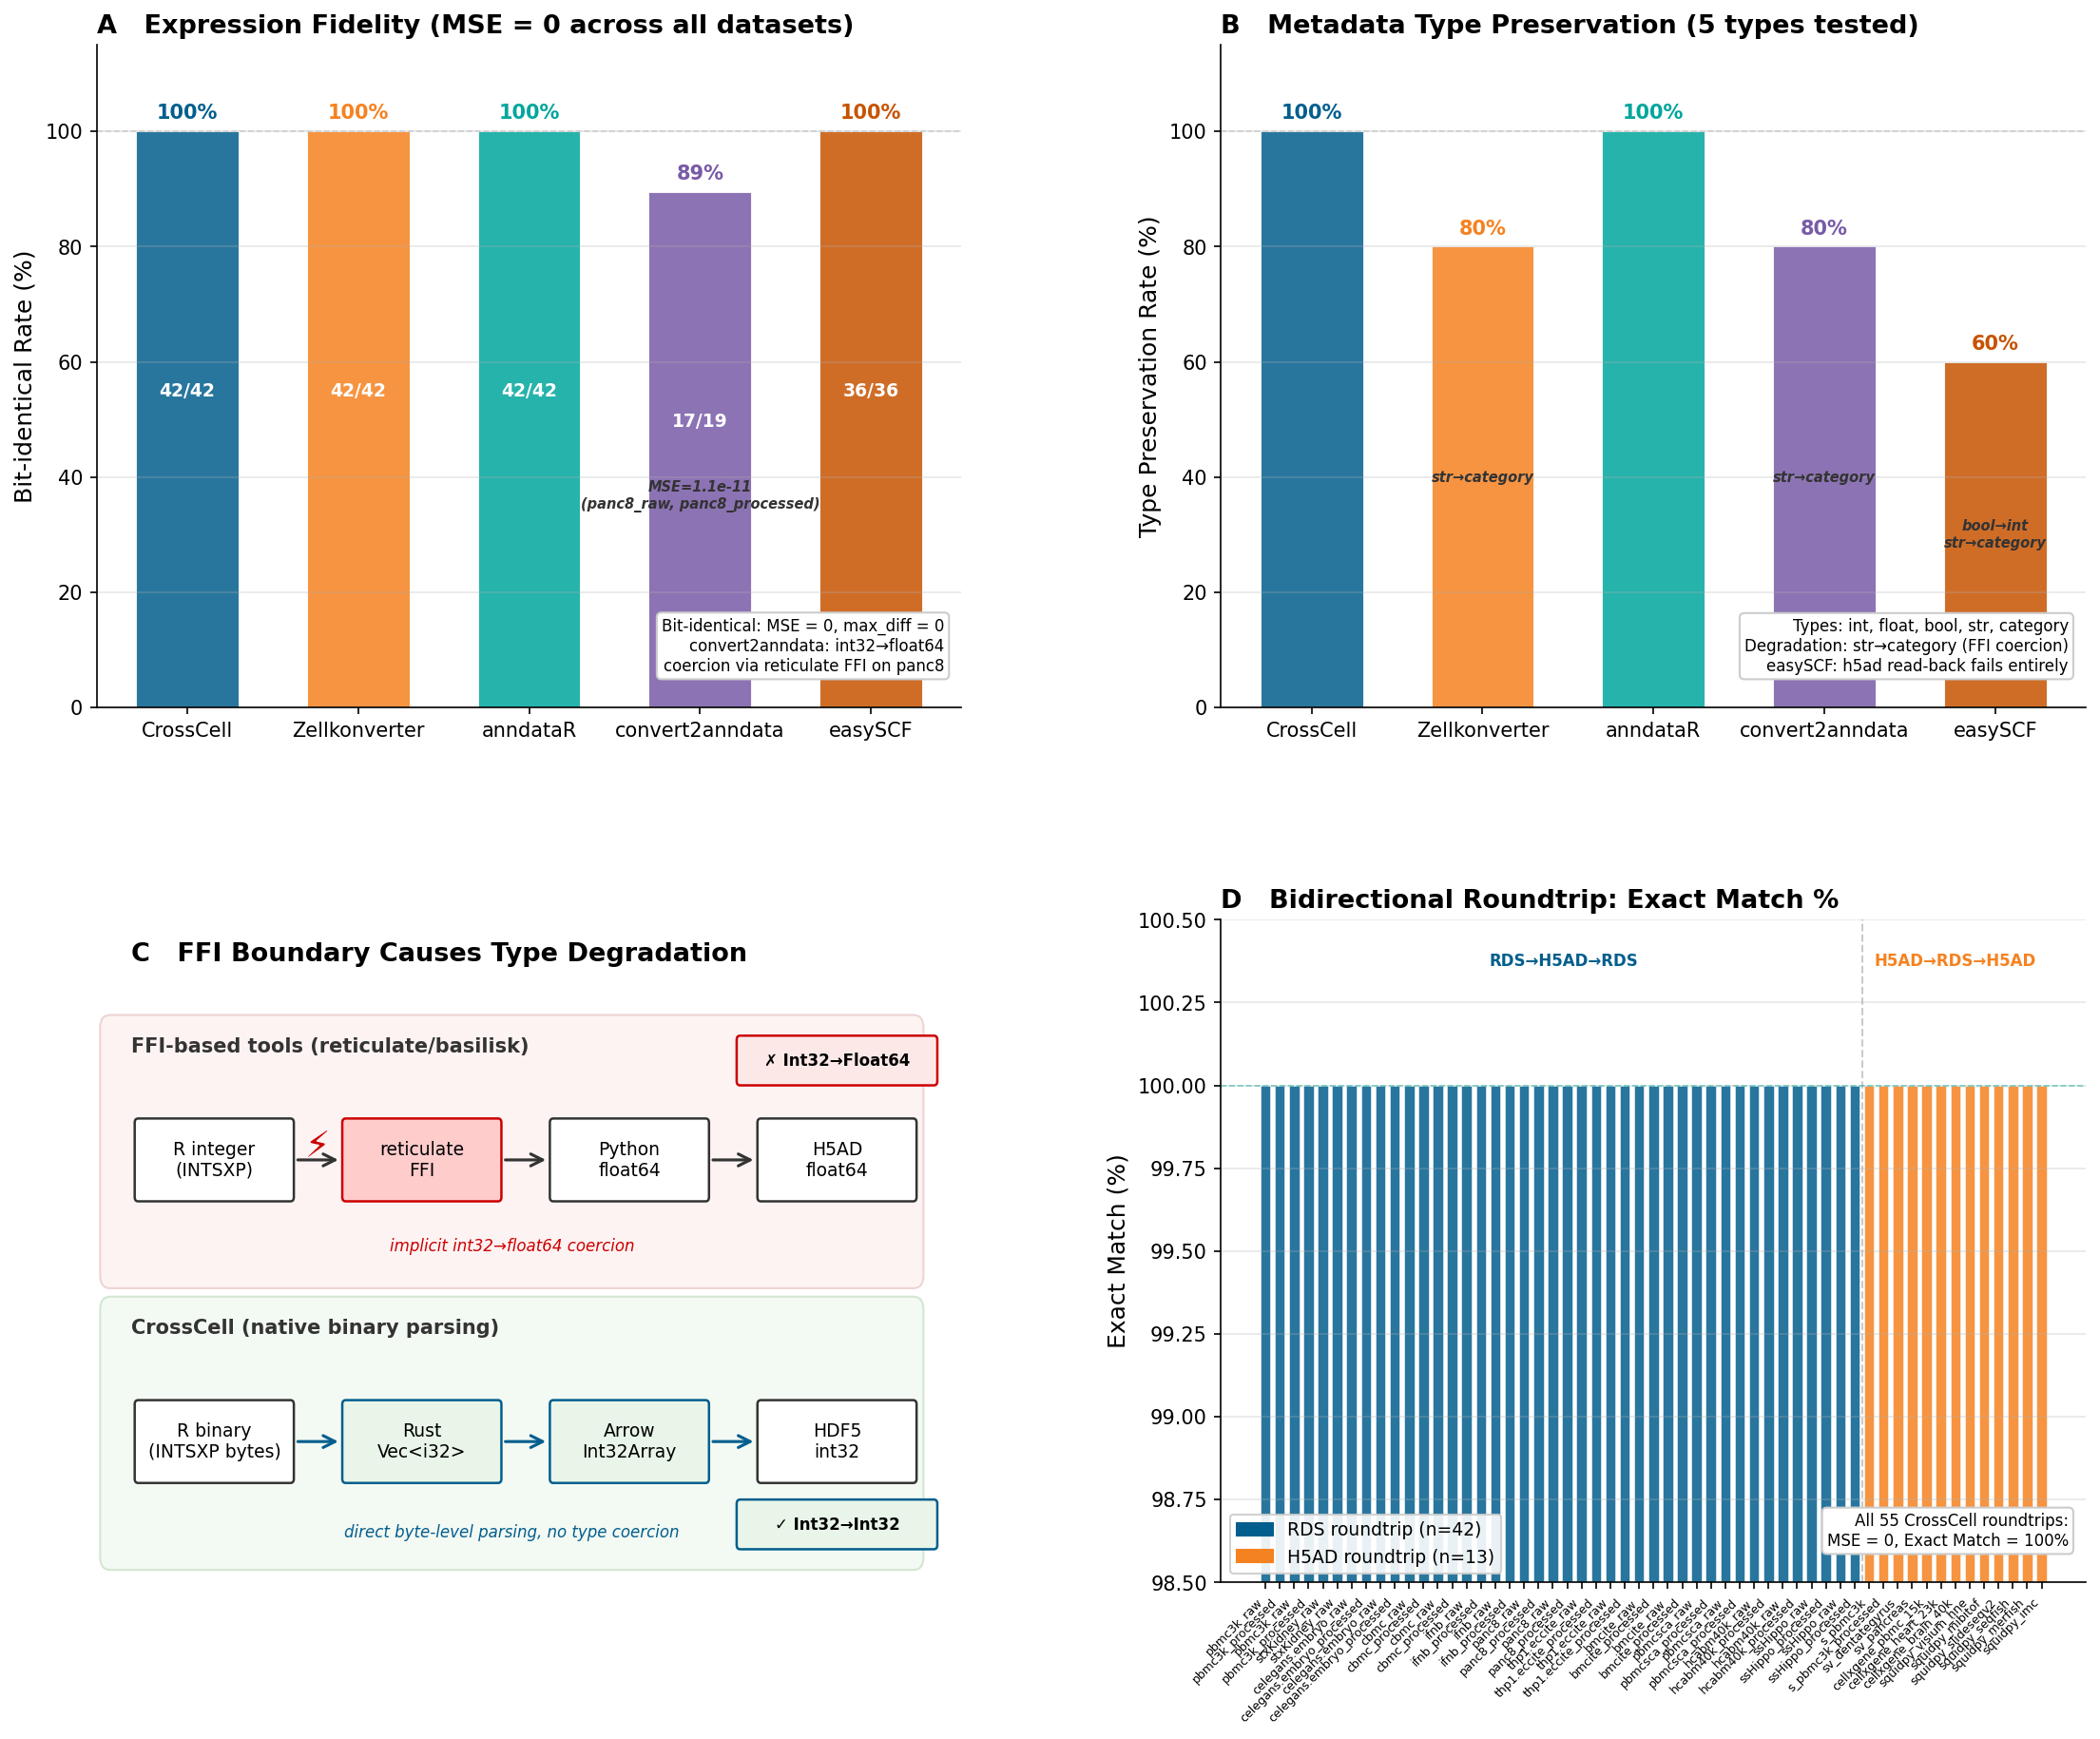

In [7]:
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch

fig = plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(2, 2, figure=fig, height_ratios=[1, 1],
                       hspace=0.32, wspace=0.3)

# ============================================================
# Panel A: Bit-identical Rate (top-left)
# ============================================================
ax_a = fig.add_subplot(gs[0, 0])

rows_dev = []
for _, e in df_cc_rt.iterrows():
    rows_dev.append({'tool': 'CrossCell', 'test_id': e['test_id'], 'mse': e['mse'],
                     'max_diff': e['max_diff']})
for _, e in df_cross[df_cross['status'] == 'success'].iterrows():
    rows_dev.append({'tool': e['tool'], 'test_id': e['test_id'], 'mse': e['mse'],
                     'max_diff': e['max_diff']})
df_dev = pd.DataFrame(rows_dev)

bit_rates = []
bit_details = []
for tool in tool_order:
    sub = df_dev[df_dev['tool'] == tool]
    n_perfect = (sub['mse'] == 0).sum()
    n_total = len(sub)
    rate = 100.0 * n_perfect / n_total if n_total > 0 else 0
    bit_rates.append(rate)
    nonzero = sub[sub['mse'] > 0]
    bit_details.append({'n_perfect': n_perfect, 'n_total': n_total, 'nonzero': nonzero})

x_a = np.arange(len(tool_order))
bars_a = ax_a.bar(x_a, bit_rates, 0.6,
                   color=[COLORS[t] for t in tool_order],
                   alpha=0.85, edgecolor='white', linewidth=0.5)

for i, (tool, rate, detail) in enumerate(zip(tool_order, bit_rates, bit_details)):
    ax_a.text(i, rate + 1.5, f'{rate:.0f}%', ha='center', va='bottom',
              fontsize=10, fontweight='bold', color=COLORS[tool])
    ax_a.text(i, rate / 2 + 5, f'{detail["n_perfect"]}/{detail["n_total"]}',
              ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    if rate < 100:
        nonzero = detail['nonzero']
        ds_names = nonzero['test_id'].str.replace('v5_', '').tolist()
        max_mse = nonzero['mse'].max()
        ax_a.text(i, rate / 2 - 8, f'MSE={max_mse:.1e}\n({", ".join(ds_names)})',
                  ha='center', va='center', fontsize=7, color='#333333',
                  fontweight='bold', style='italic')

ax_a.set_xticks(x_a)
ax_a.set_xticklabels(tool_order, fontsize=TICK_SIZE)
ax_a.set_ylabel('Bit-identical Rate (%)', fontsize=LABEL_SIZE)
ax_a.set_ylim(0, 115)
ax_a.axhline(y=100, color='#cccccc', linestyle='--', linewidth=0.8)
ax_a.set_title('A   Expression Fidelity (MSE = 0 across all datasets)',
               fontweight='bold', loc='left', fontsize=TITLE_SIZE)
ax_a.grid(axis='y', alpha=0.3)
ax_a.spines['top'].set_visible(False)
ax_a.spines['right'].set_visible(False)
ax_a.text(0.98, 0.05,
          'Bit-identical: MSE = 0, max_diff = 0\n'
          'convert2anndata: int32→float64\n'
          'coercion via reticulate FFI on panc8',
          transform=ax_a.transAxes, fontsize=NOTE_SIZE, va='bottom', ha='right',
          bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#cccccc'))

# ============================================================
# Panel B: Type Preservation (top-right)
# ============================================================
ax_b = fig.add_subplot(gs[0, 1])

retention = type_data['retention']
type_results = type_data['type_results']
expected = type_data['expected_types']
rates = [retention[t] for t in tool_order]

bars_b = ax_b.bar(np.arange(len(tool_order)), rates, 0.6,
                  color=[COLORS[t] for t in tool_order],
                  alpha=0.85, edgecolor='white', linewidth=0.5)

for i, (tool, rate) in enumerate(zip(tool_order, rates)):
    ax_b.text(i, rate + 1.5, f'{rate:.0f}%', ha='center', va='bottom',
              fontsize=10, fontweight='bold', color=COLORS[tool])
    actual = type_results[tool]
    degraded = []
    for col, exp_type in expected.items():
        act_type = actual.get(col, 'missing')
        if act_type == 'READ_ERROR':
            degraded.append(f'{col}: READ ERROR')
        elif act_type != exp_type:
            degraded.append(f'{exp_type}→{act_type}')
    if degraded and rate > 0:
        ax_b.text(i, rate / 2, '\n'.join(degraded), ha='center', va='center',
                  fontsize=7, color='#333333', fontweight='bold', style='italic')
    elif rate == 0:
        ax_b.text(i, 8, 'ALL READ\nERROR', ha='center', va='bottom',
                  fontsize=8, color=COLORS[tool], fontweight='bold')
        ax_b.text(i, 2, '(cannot read\nback h5ad)', ha='center', va='bottom',
                  fontsize=6, color='#999999', style='italic')

ax_b.set_xticks(np.arange(len(tool_order)))
ax_b.set_xticklabels(tool_order, fontsize=TICK_SIZE)
ax_b.set_ylabel('Type Preservation Rate (%)', fontsize=LABEL_SIZE)
ax_b.set_ylim(0, 115)
ax_b.axhline(y=100, color='#cccccc', linestyle='--', linewidth=0.8)
ax_b.set_title('B   Metadata Type Preservation (5 types tested)',
               fontweight='bold', loc='left', fontsize=TITLE_SIZE)
ax_b.grid(axis='y', alpha=0.3)
ax_b.spines['top'].set_visible(False)
ax_b.spines['right'].set_visible(False)
ax_b.text(0.98, 0.05, 'Types: int, float, bool, str, category\n'
          'Degradation: str→category (FFI coercion)\n'
          'easySCF: h5ad read-back fails entirely',
          transform=ax_b.transAxes, fontsize=NOTE_SIZE, va='bottom', ha='right',
          bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#cccccc'))

# ============================================================
# Panel C: FFI Mechanism Schematic (bottom-left) — NO evidence box
# ============================================================
ax_c = fig.add_subplot(gs[1, 0])
ax_c.set_xlim(-0.5, 12)
ax_c.set_ylim(-0.5, 7.5)
ax_c.axis('off')

def draw_box(ax, x, y, w, h, text, facecolor='white', edgecolor='black', fontsize=9, bold=False):
    box = FancyBboxPatch((x - w/2, y - h/2), w, h,
                         boxstyle='round,pad=0.05', facecolor=facecolor,
                         edgecolor=edgecolor, linewidth=1.2)
    ax.add_patch(box)
    fw = 'bold' if bold else 'normal'
    ax.text(x, y, text, ha='center', va='center', fontsize=fontsize, fontweight=fw)

def draw_arrow_c(ax, x1, y1, x2, y2, color='black'):
    arrow = FancyArrowPatch((x1, y1), (x2, y2),
                            arrowstyle='->', mutation_scale=15,
                            color=color, linewidth=1.5)
    ax.add_patch(arrow)

ax_c.text(0, 7.0, 'C   FFI Boundary Causes Type Degradation',
          fontsize=TITLE_SIZE, fontweight='bold')

bg_top = FancyBboxPatch((-0.3, 3.2), 11.6, 3.0,
                         boxstyle='round,pad=0.15', facecolor='#fde8e8',
                         edgecolor='#e0b0b0', linewidth=1, alpha=0.5)
ax_c.add_patch(bg_top)
ax_c.text(0, 5.9, 'FFI-based tools (reticulate/basilisk)', fontsize=10,
          fontweight='bold', color='#333333')

bw, bh = 2.2, 0.9
y_top = 4.6
boxes_top = [
    (1.2, y_top, 'R integer\n(INTSXP)', 'white', '#333333'),
    (4.2, y_top, 'reticulate\nFFI', '#ffcccc', '#cc0000'),
    (7.2, y_top, 'Python\nfloat64', 'white', '#333333'),
    (10.2, y_top, 'H5AD\nfloat64', 'white', '#333333'),
]
for bx, by, txt, fc, ec in boxes_top:
    draw_box(ax_c, bx, by, bw, bh, txt, facecolor=fc, edgecolor=ec, fontsize=9)
for i in range(len(boxes_top) - 1):
    x1 = boxes_top[i][0] + bw/2 + 0.05
    x2 = boxes_top[i+1][0] - bw/2 - 0.05
    draw_arrow_c(ax_c, x1, y_top, x2, y_top, color='#333333')
ax_c.text(2.7, y_top + 0.15, '⚡', fontsize=18, ha='center', va='center', color='#cc0000')

bg_bot = FancyBboxPatch((-0.3, -0.2), 11.6, 3.0,
                         boxstyle='round,pad=0.15', facecolor='#e8f5e8',
                         edgecolor='#b0d0b0', linewidth=1, alpha=0.5)
ax_c.add_patch(bg_bot)
ax_c.text(0, 2.5, 'CrossCell (native binary parsing)', fontsize=10,
          fontweight='bold', color='#333333')

y_bot = 1.2
boxes_bot = [
    (1.2, y_bot, 'R binary\n(INTSXP bytes)', 'white', '#333333'),
    (4.2, y_bot, 'Rust\nVec<i32>', '#e8f5e8', '#025e8d'),
    (7.2, y_bot, 'Arrow\nInt32Array', '#e8f5e8', '#025e8d'),
    (10.2, y_bot, 'HDF5\nint32', 'white', '#333333'),
]
for bx, by, txt, fc, ec in boxes_bot:
    draw_box(ax_c, bx, by, bw, bh, txt, facecolor=fc, edgecolor=ec, fontsize=9)
for i in range(len(boxes_bot) - 1):
    x1 = boxes_bot[i][0] + bw/2 + 0.05
    x2 = boxes_bot[i+1][0] - bw/2 - 0.05
    draw_arrow_c(ax_c, x1, y_bot, x2, y_bot, color='#025e8d')

ax_c.text(5.5, 3.5, 'implicit int32→float64 coercion', fontsize=8,
          color='#cc0000', style='italic', ha='center')
ax_c.text(5.5, 0.05, 'direct byte-level parsing, no type coercion', fontsize=8,
          color='#025e8d', style='italic', ha='center')

# Result labels on right side
draw_box(ax_c, 10.2, y_top + 1.2, 2.8, 0.5, '✗ Int32→Float64', facecolor='#fde8e8', edgecolor='#cc0000', fontsize=8, bold=True)
draw_box(ax_c, 10.2, y_bot - 1.0, 2.8, 0.5, '✓ Int32→Int32', facecolor='#e8f5e8', edgecolor='#025e8d', fontsize=8, bold=True)

# ============================================================
# Panel D: Exact Match % (bottom-right)
# ============================================================
ax_d = fig.add_subplot(gs[1, 1])

datasets_rds = df_rds_rt['dataset'].tolist()
datasets_h5ad = df_h5ad_rt['dataset'].tolist()
all_datasets_d = datasets_rds + datasets_h5ad
match_vals = list(df_rds_rt['exact_match_pct']) + list(df_h5ad_rt['exact_match_pct'])

x_d = np.arange(len(all_datasets_d))
colors_d = ['#025e8d'] * len(datasets_rds) + ['#f58220'] * len(datasets_h5ad)
ax_d.bar(x_d, match_vals, 0.7, color=colors_d, alpha=0.85,
         edgecolor='white', linewidth=0.3)

ax_d.set_ylim(98.5, 100.5)

short_d = [d.replace('v4_', '').replace('v5_', '').replace('scanpy_', 's_').replace('scvelo_', 'sv_')
           for d in all_datasets_d]
ax_d.set_xticks(x_d)
ax_d.set_xticklabels(short_d, fontsize=6, rotation=45, ha='right')
ax_d.set_ylabel('Exact Match (%)', fontsize=LABEL_SIZE)

sep_d = len(datasets_rds) - 0.5
ax_d.axvline(x=sep_d, color='#999', linestyle='--', linewidth=1, alpha=0.5)
ax_d.text(sep_d / 2, 100.4, 'RDS→H5AD→RDS', fontsize=ANNOT_SIZE,
          ha='center', va='top', color='#025e8d', fontweight='bold')
ax_d.text(sep_d + len(datasets_h5ad) / 2, 100.4, 'H5AD→RDS→H5AD', fontsize=ANNOT_SIZE,
          ha='center', va='top', color='#f58220', fontweight='bold')

ax_d.legend(handles=[Patch(color='#025e8d', label=f'RDS roundtrip (n={len(datasets_rds)})'),
                     Patch(color='#f58220', label=f'H5AD roundtrip (n={len(datasets_h5ad)})')],
            fontsize=LEGEND_SIZE, loc='lower left', framealpha=0.9)

ax_d.axhline(y=100, color='#00a69d', linestyle='--', linewidth=0.8, alpha=0.5)
ax_d.text(0.98, 0.05, f'All {len(all_datasets_d)} CrossCell roundtrips:\nMSE = 0, Exact Match = 100%',
          transform=ax_d.transAxes, fontsize=NOTE_SIZE, va='bottom', ha='right',
          bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#cccccc'))

ax_d.set_title('D   Bidirectional Roundtrip: Exact Match %',
               fontweight='bold', loc='left', fontsize=TITLE_SIZE)
ax_d.grid(axis='y', alpha=0.3)
ax_d.spines['top'].set_visible(False)
ax_d.spines['right'].set_visible(False)

# ── Save ──
plt.savefig(FIGURES_DIR / 'fig5_fidelity_composite.pdf', bbox_inches='tight')
plt.savefig(FIGURES_DIR / 'fig5_fidelity_composite.png', bbox_inches='tight')
print('✅ Saved fig5_fidelity_composite')
plt.show()
